# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [2]:
# Inspect the shapes of the train/test datasets
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [3]:
# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
print(f'Before one-hot encoding: {y_train[0]}')
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
print(f'After one-hot encoding: {y_train[0]}')

Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


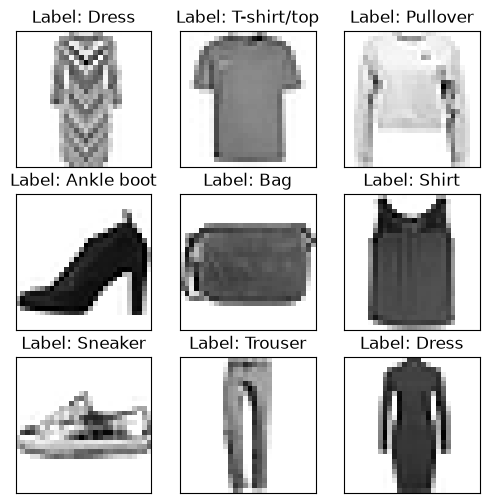

In [4]:
# Data visualization to understand what it looks like.
import numpy as np
import matplotlib.pyplot as plt

# Selecting 9 random indices
random_indices = np.random.choice(len(X_train), 9, replace=False)

# Creating a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    label = np.argmax(y_train[random_indices[i]])
    ax.imshow(X_train[random_indices[i]], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label: {class_names[label]}")

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**
-- The training data do have overall good image-label correspondence. However, the images are very low resolution. I didn't notice any issue at the images, though I only glanced over and didn't inspect the thousands of images.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [5]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten
from keras.optimizers import Adam

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Input(shape=(28,28,1)))    
model.add(Flatten())    # Convert 2D images into 1D vectors
model.add(Dense(64,))  # Equivalent to simple linear regression model
model.add(Dense(10, activation='softmax'))  # Output layer matching the number of classes in the dataset, i.e., 10 neurons.

# Compile the model using `model.compile()`
tf.keras.utils.set_random_seed(42)  #reproducibility to allow comparison between models
model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer=Adam(), # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

# Train the model with `model.fit()`
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=10, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/10


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 955us/step - accuracy: 0.8054 - loss: 0.5607 - val_accuracy: 0.8293 - val_loss: 0.4890
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 924us/step - accuracy: 0.8400 - loss: 0.4596 - val_accuracy: 0.8273 - val_loss: 0.4858
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 891us/step - accuracy: 0.8475 - loss: 0.4398 - val_accuracy: 0.8316 - val_loss: 0.4751
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 880us/step - accuracy: 0.8510 - loss: 0.4287 - val_accuracy: 0.8356 - val_loss: 0.4660
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 876us/step - accuracy: 0.8535 - loss: 0.4210 - val_accuracy: 0.8374 - val_loss: 0.4591
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 865us/step - accuracy: 0.8556 - loss: 0.4152 - val_accuracy: 0.8393 - val_loss: 0.4541
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 875us/step - accuracy: 0.8568 - loss: 0.4104 - val_accuracy: 0.8420 - val_loss: 0.4505
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 872us/step - accuracy: 0.8577 - loss: 0.40

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**
-- The linear regression model achieved 0.48 loss (categorical_crossentropy) and 83.14% accuracy. Honestly, for a linear regression model to classify images it did pretty good, I was expecting loss to be higer and accuracy much lower. Nevertheless, there is room for improvement and i think the main challenge is on moving the images classification boundaries from lines to more intricate patterns. 

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [6]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten, Conv2D
from keras.optimizers import Adam

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Input(shape=(28,28,1)))    
model.add(Conv2D(64, 3, activation='relu')) # Convolutional layer (learn spatial hierarchies in imagies)
model.add(Flatten())    # Flattening the output of Convolutional layer to input in prediction layer
model.add(Dense(64,activation='relu'))  # Fully connected layer (to make predictions)
model.add(Dense(10, activation='softmax'))  # Output layer matching the number of classes in the dataset, i.e., 10 neurons.

# Compile the model using `model.compile()`
tf.keras.utils.set_random_seed(42)  #reproducibility to allow comparison between models
model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer=Adam(), # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

# Train the model with `model.fit()`
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=10, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8583 - loss: 0.3912 - val_accuracy: 0.8894 - val_loss: 0.3052
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9074 - loss: 0.2535 - val_accuracy: 0.8980 - val_loss: 0.2840
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9289 - loss: 0.1929 - val_accuracy: 0.9009 - val_loss: 0.2856
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9495 - loss: 0.1441 - val_accuracy: 0.8961 - val_loss: 0.3286
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9623 - loss: 0.1086 - val_accuracy: 0.8940 - val_loss: 0.3851
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9721 - loss: 0.0812 - val_accuracy: 0.8983 - val_loss: 0.4213
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9775 - loss: 0.0647 - val_accuracy: 0.8973 - val_loss: 0.4423
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9814 - loss: 0.0532 

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**
-- The simple CNN model improved prediction accuracy by ~ 6% in comparsion to the linear regression model. However, that came at the expense of confidence in their predictions (i.e., the loss was higher, 0.59 in the simple CNN in comparison to 0.48 in the linear regression model). The improved accuracy suggests the CNN model was overall more effective than the the baseline model, despite the higher loss. I believe the main factor contributing to this improvement was the presence of a convolutional layer, which allowed the model to learn spatial hierarchies and local patterns in the images and, therefore, improve prediction accuracy.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [7]:
# A. Test Hyperparameters
# Step1 - Import libraries
import tensorflow as tf
import pandas as pd
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten, Conv2D
from keras.optimizers import Adam

# Step2 - Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Step3 - Create a CNN model to experiment with convolutionnal layer filter hyperparmeter optimization.
def model_hyper_optimization(filter):
    model = Sequential()
    # You can use `model.add(<layer>)` to add layers to the model
    model.add(Input(shape=(28,28,1)))    
    model.add(Conv2D(filter, 3, activation='relu')) # Convolutional layer (learn spatial hierarchies in imagies)
    model.add(Flatten())    # Flattening the output of Convolutional layer to input in prediction layer
    model.add(Dense(64,activation='relu'))  # Fully connected layer (to make predictions)
    model.add(Dense(10, activation='softmax'))  # Output layer matching the number of classes in the dataset, i.e., 10 neurons.

    return model

# Step4 - Run a for loop to compare models with different filter sizes.
results = []    # empty list created to store values for comparison

for filter in [32,64,128,256]:
    tf.keras.utils.set_random_seed(42)  #reproducibility to allow comparison between models
    
    # Step5 - Compile the model using `model.compile()`. 
    model = model_hyper_optimization(filter)
    model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer=Adam(), # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
    )

    # Step6 - Train the model with `model.fit()`
    model.fit(
        X_train, # Training data
        y_train, # Training labels
        epochs=10, # Number of epochs
        batch_size=32, # Number of samples per batch
        validation_split=0.2 # Use 20% of the data for validation
    )

    # Step7 - Evaluate the model with `model.evaluate()`
    loss, accuracy = model.evaluate(X_test, y_test)
    
    # Step8 - Store evaluation values in list object
    results.append([filter, loss, accuracy])

# Step9 - Use pandas DataFrame to display results
df = pd.DataFrame(
    results,
    columns=["Number of filters", "Loss", "Accuracy"]
    )
df

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8518 - loss: 0.4136 - val_accuracy: 0.8863 - val_loss: 0.3213
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8996 - loss: 0.2757 - val_accuracy: 0.8917 - val_loss: 0.3063
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9188 - loss: 0.2244 - val_accuracy: 0.8962 - val_loss: 0.2967
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9334 - loss: 0.1848 - val_accuracy: 0.8979 - val_loss: 0.3076
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9467 - loss: 0.1501 - val_accuracy: 0.8962 - val_loss: 0.3345
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9577 - loss: 0.1209 - val_accuracy: 0.8984 - val_loss: 0.3605
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9671 - loss: 0.0956 - val_accuracy: 0.8967 - val_loss: 0.3882
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9733 - loss: 0.0773 - 

,Number of filters,Loss,Accuracy
0,32,0.535504,0.8890
1,64,0.589343,0.8961
2,128,0.682127,0.8810
3,256,0.612823,0.8981


In [8]:
# B. Test presence or absence of regularization
# Step1 - Import libraries
import tensorflow as tf
import pandas as pd
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten, Conv2D, Dropout
from keras.optimizers import Adam

# Step2 - Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Step3 - Create a CNN model to experiment with regularization.
def model_dropout_optimization(dropout_rate):
    model = Sequential()
    # You can use `model.add(<layer>)` to add layers to the model
    model.add(Input(shape=(28,28,1)))    
    model.add(Conv2D(32, 3, activation='relu')) # Convolutional layer (learn spatial hierarchies in imagies)
    model.add(Flatten())    # Flattening the output of Convolutional layer to input in prediction layer
    model.add(Dense(64,activation='relu'))  # Fully connected layer (to make predictions)
    # Adding dropout layer with different rates
    if dropout_rate > 0.00:
        model.add(Dropout(dropout_rate))  # Add dropout layer with varying dropout_rate
        
    model.add(Dense(10, activation='softmax'))  # Output layer matching the number of classes in the dataset, i.e., 10 neurons.

    return model

# Step4 - Run a for loop to compare models with absence and presence of dropout at different dropout rates.
results_1 = []    # empty list created to store values for comparison

for drop_rate in [0.00, 0.10, 0.20, 0.30, 0.40, 0.50]:
    tf.keras.utils.set_random_seed(42)  #reproducibility to allow comparison between models
    
    # Step5 - Compile the model using `model.compile()`. 
    model = model_dropout_optimization(drop_rate)
    model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer=Adam(), # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
    )

    # Step6 - Train the model with `model.fit()`
    model.fit(
        X_train, # Training data
        y_train, # Training labels
        epochs=10, # Number of epochs
        batch_size=32, # Number of samples per batch
        validation_split=0.2 # Use 20% of the data for validation
    )

    # Step7 - Evaluate the model with `model.evaluate()`
    loss, accuracy = model.evaluate(X_test, y_test)
    
    # Step8 - Store evaluation values in list object
    results_1.append([drop_rate, loss, accuracy])

# Step9 - Use pandas DataFrame to display results
df = pd.DataFrame(
    results_1,
    columns=["Dropout rate", "Loss", "Accuracy"]
    )
df

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8518 - loss: 0.4136 - val_accuracy: 0.8863 - val_loss: 0.3213
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8996 - loss: 0.2757 - val_accuracy: 0.8917 - val_loss: 0.3063
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9188 - loss: 0.2244 - val_accuracy: 0.8962 - val_loss: 0.2967
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9334 - loss: 0.1848 - val_accuracy: 0.8979 - val_loss: 0.3076
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9467 - loss: 0.1501 - val_accuracy: 0.8962 - val_loss: 0.3345
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9577 - loss: 0.1209 - val_accuracy: 0.8984 - val_loss: 0.3605
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9671 - loss: 0.0956 - val_accuracy: 0.8967 - val_loss: 0.3882
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9733 - loss: 0

,Dropout rate,Loss,Accuracy
0,0.0,0.535504,0.8890
1,0.1,0.422704,0.8969
2,0.2,0.367700,0.8978
3,0.3,0.330635,0.8983
4,0.4,0.314390,0.8998
5,0.5,0.307897,0.8959


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**
-Changing the number of convolutional filters did not improve performance. Increasing the filters from 32 to 256 resulted in higher training losses and did not consistently increase accuracy. The best accuracy (89.8%) was achieved using 32 filters, suggesting that the baseline model already had sufficient capacity to learn the relevant image features, and adding more filters mainly increased model complexity without providing additional useful representations. 
Increasing the dropout rate from 0.0 to 0.5 consistently reduced the training loss. Model accuracy also improved slightly, with a maximum of 89.98% at a dropout rate of 0.4. This suggests that dropout helped reduce overfitting by preventing the network from relying too heavily on individual neurons, leading to better generalization.
The best-performing model therefore used 32 convolutional filters combined with 0.4 dropout.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [9]:
# Compiling finalm model
# Step1 - Import libraries
import tensorflow as tf
import pandas as pd
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten, Conv2D, Dropout
from keras.optimizers import Adam

# Step2 - Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Step3 - Create optimal CNN model based on experimentation.
def optimal_model():
    model = Sequential()
    # You can use `model.add(<layer>)` to add layers to the model
    model.add(Input(shape=(28,28,1)))    
    model.add(Conv2D(32, 3, activation='relu')) # Convolutional layer (learn spatial hierarchies in imagies)
    model.add(Flatten())    # Flattening the output of Convolutional layer to input in prediction layer
    model.add(Dense(64,activation='relu'))  # Fully connected layer (to make predictions)
    model.add(Dropout(0.4))  # Add dropout layer with varying dropout_rate
    model.add(Dense(10, activation='softmax'))  # Output layer matching the number of classes in the dataset, i.e., 10 neurons.

    return model

tf.keras.utils.set_random_seed(42)  #reproducibility to allow comparison between models
    
# Step5 - Compile the model using `model.compile()`. 
model = optimal_model()
model.compile(
loss='categorical_crossentropy', # Loss function
optimizer=Adam(), # Optimizer
metrics=['accuracy'] # Metrics to evaluate the model
)

# Step6 - Train the model with `model.fit()`
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=10, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
    )

# Step7 - Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test)
    
# Step9 - Use pandas DataFrame to display results
df = pd.DataFrame({
    "Loss": [loss],
    "Accuracy": [accuracy]
})
df

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8051 - loss: 0.5548 - val_accuracy: 0.8677 - val_loss: 0.3618
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8609 - loss: 0.3875 - val_accuracy: 0.8852 - val_loss: 0.3139
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8781 - loss: 0.3404 - val_accuracy: 0.8898 - val_loss: 0.3008
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8871 - loss: 0.3099 - val_accuracy: 0.8903 - val_loss: 0.2939
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8943 - loss: 0.2841 - val_accuracy: 0.8957 - val_loss: 0.2886
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9028 - loss: 0.2605 - val_accuracy: 0.8988 - val_loss: 0.2880
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9101 - loss: 0.2421 - val_accuracy: 0.9024 - val_loss: 0.2792
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9139 - loss: 0

,Loss,Accuracy
0,0.31439,0.8998


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**
- The final model achieved the best overall performance, with an accuracy of 89.98%, outperforming both the linear regression model (83.14%) and the simple CNN (89.61%). Although the accuracy improvement over the simple CNN was modest (approximately 0.4 percentage points), the substantially lower loss suggests that the final model is more confident in the predictions. The primary contributor to the performance improvement was the addition of the convolutional layer, which enabled the model to learn local features and spatial hierarchies in the images. The addition of dropout regularization reduced overfitting by preventing the network from relying too heavily on individual neurons and, therefore, improved prediction confidence. Given more time, I would conduct more systematic investigation including:  number of convolutional layer, presence of max-pooling layers, number of kernel sizes, varying learning rates, number of training epochs, and evaluating other regularization techniques such as L2 weight decay. These experiments could help determine whether the model's performance can be further improved while maintaining good generalization.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.